In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
CSV_PATH = 'sales_data.csv'

def generate_synthetic_sales_data(path=CSV_PATH, n_rows=400, seed=42):
    rng = np.random.default_rng(seed)
    products = ['Widget A', 'Widget B', 'Widget C', 'Widget D']
    regions = ['North', 'South', 'East', 'West']
    dates = pd.date_range(start='2024-01-01', periods=n_rows, freq='D')
    data = {'Date': dates, 'Product': rng.choice(products, size=n_rows), 'Region': rng.choice(regions, size=n_rows), 'Sales': rng.integers(100, 5000, size=n_rows).astype(float), 'Quantity': rng.integers(1, 50, size=n_rows)}
    df = pd.DataFrame(data)
    margin = rng.uniform(0.1, 0.3, size=n_rows)
    df['Profit'] = (df['Sales'] * margin).round(2)
    missing_idx = rng.choice(df.index, size=int(n_rows * 0.05), replace=False)
    df.loc[missing_idx, 'Sales'] = np.nan
    missing_idx2 = rng.choice(df.index, size=int(n_rows * 0.03), replace=False)
    df.loc[missing_idx2, 'Profit'] = np.nan
    df.to_csv(path, index=False)
    print(f"Synthetic dataset with {n_rows} rows written to '{path}'.")
    return df
_ = generate_synthetic_sales_data()

Synthetic dataset with 400 rows written to 'sales_data.csv'.


In [3]:
class SalesDataAnalyzer:

    def __init__(self, file_path=None):
        self.data = pd.DataFrame()
        self.file_path = file_path
        if file_path is not None:
            self.load_data(file_path)
        print(f"[SalesDataAnalyzer] Instance created for '{file_path}'.")

    def __del__(self):
        try:
            print(f"[SalesDataAnalyzer] Instance for '{self.file_path}' is being destroyed. Cleanup done.")
        except Exception:
            pass

    def __add__(self, other):
        if isinstance(other, SalesDataAnalyzer):
            combined = pd.concat([self.data, other.data], ignore_index=True)
            new_analyzer = SalesDataAnalyzer.__new__(SalesDataAnalyzer)
            new_analyzer.data = combined
            new_analyzer.file_path = 'combined_via_operator_overload'
            return new_analyzer
        return NotImplemented

    def __len__(self):
        return len(self.data)

    def __repr__(self):
        return f"SalesDataAnalyzer(rows={len(self.data)}, file='{self.file_path}')"

    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(file_path, parse_dates=['Date'])
            self.file_path = file_path
            print(f"Data loaded successfully from '{file_path}'. Shape: {self.data.shape}")
        except FileNotFoundError:
            print(f"ERROR: File '{file_path}' was not found.")
        except pd.errors.EmptyDataError:
            print(f"ERROR: File '{file_path}' is empty.")
        except Exception as e:
            print(f'ERROR: Could not load data due to: {e}')

    def explore_data(self):
        if self.data.empty:
            print('No data loaded yet.')
            return
        print('=' * 60)
        print('HEAD (first 5 rows)')
        print('=' * 60)
        print(self.data.head())
        print('\n' + '=' * 60)
        print('INFO')
        print('=' * 60)
        self.data.info()
        print('\n' + '=' * 60)
        print('DESCRIBE (numeric summary statistics)')
        print('=' * 60)
        print(self.data.describe())

    def clean_data(self):
        if self.data.empty:
            print('No data loaded yet.')
            return
        print('Missing values BEFORE cleaning:')
        print(self.data.isnull().sum())
        for col in ['Sales', 'Profit']:
            if col in self.data.columns and self.data[col].isnull().any():
                self.data[col] = self.data[col].fillna(self.data[col].mean())
        self.data = self.data.dropna(subset=['Product', 'Region'])
        if 'Date' in self.data.columns:
            self.data['Date'] = pd.to_datetime(self.data['Date'], errors='coerce')
        for col in ['Sales', 'Profit']:
            if col in self.data.columns:
                self.data[col] = self.data[col].astype(float)
        if 'Quantity' in self.data.columns:
            self.data['Quantity'] = self.data['Quantity'].astype(int)
        print('\nMissing values AFTER cleaning:')
        print(self.data.isnull().sum())
        print('\nData types after conversion:')
        print(self.data.dtypes)

    def mathematical_operations(self):
        if self.data.empty:
            print('No data loaded yet.')
            return None
        self.data['Profit_Margin_%'] = (self.data['Profit'] / self.data['Sales'] * 100).round(2)
        self.data['Sales_With_10pct_Increase'] = self.data['Sales'] * 1.1
        print('New computed columns (first 5 rows):')
        print(self.data[['Sales', 'Profit', 'Profit_Margin_%', 'Sales_With_10pct_Increase']].head())
        return self.data

    def numpy_array_operations(self):
        if self.data.empty:
            print('No data loaded yet.')
            return
        sales_arr = self.data['Sales'].to_numpy()
        profit_arr = self.data['Profit'].to_numpy()
        print(f'Sales array shape: {sales_arr.shape}, dtype: {sales_arr.dtype}')
        print(f'First sale value: {sales_arr[0]}')
        print(f'Last sale value: {sales_arr[-1]}')
        print(f'First 5 sales: {sales_arr[:5]}')
        print(f'Every 10th sale value: {sales_arr[::10][:5]} ...')
        total_revenue_proxy = sales_arr + profit_arr
        scaled_sales = sales_arr * 1.05
        sales_minus_profit = sales_arr - profit_arr
        print(f'Sales + Profit (first 5): {total_revenue_proxy[:5]}')
        print(f'Sales * 1.05  (first 5): {scaled_sales[:5]}')
        print(f'Sales - Profit (first 5): {sales_minus_profit[:5]}')
        high_sales_mask = sales_arr > 4000
        print(f'Number of sales above 4000: {high_sales_mask.sum()}')

    def combine_data(self, other_dataframe, how='concat', on=None):
        if how == 'concat':
            self.data = pd.concat([self.data, other_dataframe], ignore_index=True)
        elif how == 'merge':
            self.data = pd.merge(self.data, other_dataframe, on=on, how='left')
        elif how == 'join':
            self.data = self.data.join(other_dataframe, how='left', rsuffix='_other')
        else:
            print(f'Unknown combine method: {how}')
            return
        print(f"Data combined using '{how}'. New shape: {self.data.shape}")

    def split_data(self, criteria_column='Region'):
        if criteria_column not in self.data.columns:
            print(f"Column '{criteria_column}' not found.")
            return {}
        groups = {value: sub_df for value, sub_df in self.data.groupby(criteria_column)}
        print(f"Data split into {len(groups)} groups by '{criteria_column}': {list(groups.keys())}")
        return groups

    def search_sort_filter(self, search_value=None, search_column='Product', sort_by='Sales', ascending=False, filter_column='Region', filter_value=None):
        result = self.data.copy()
        if search_value is not None and search_column in result.columns:
            result = result[result[search_column].astype(str).str.contains(str(search_value), case=False, na=False)]
            print(f"Search: {len(result)} rows match '{search_value}' in '{search_column}'.")
        if filter_value is not None and filter_column in result.columns:
            result = result[result[filter_column] == filter_value]
            print(f"Filter: {len(result)} rows where {filter_column} == '{filter_value}'.")
        if sort_by in result.columns:
            result = result.sort_values(by=sort_by, ascending=ascending)
            print(f"Sorted by '{sort_by}' ({('ascending' if ascending else 'descending')}).")
        return result

    def aggregate_functions(self, group_by='Region'):
        if group_by not in self.data.columns:
            print(f"Column '{group_by}' not found.")
            return None
        summary = self.data.groupby(group_by).agg(Total_Sales=('Sales', 'sum'), Average_Sales=('Sales', 'mean'), Total_Profit=('Profit', 'sum'), Record_Count=('Sales', 'count')).round(2)
        print(f"Aggregated metrics grouped by '{group_by}':")
        print(summary)
        return summary

    def statistical_analysis(self):
        numeric_cols = self.data.select_dtypes(include=[np.number])
        stats = pd.DataFrame({'mean': numeric_cols.mean(), 'std': numeric_cols.std(), 'var': numeric_cols.var(), '25%': numeric_cols.quantile(0.25), '50% (median)': numeric_cols.quantile(0.5), '75%': numeric_cols.quantile(0.75)}).round(2)
        print('Statistical summary of numeric columns:')
        print(stats)
        return stats

    def create_pivot_table(self, index='Region', columns='Product', values='Sales', aggfunc='sum'):
        pivot = pd.pivot_table(self.data, index=index, columns=columns, values=values, aggfunc=aggfunc, fill_value=0)
        print(f'Pivot table ({aggfunc} of {values}, rows={index}, cols={columns}):')
        print(pivot)
        return pivot

    def reindex_demo(self):
        by_region = self.data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
        custom_order = ['North', 'South', 'East', 'West']
        reindexed = by_region.reindex(custom_order)
        reindexed.index.name = 'Region (custom order)'
        print('Re-indexed total sales by region:')
        print(reindexed)
        return reindexed

    def groupby_transform_demo(self):
        self.data['Region_Sales_Share_%'] = (self.data['Sales'] / self.data.groupby('Region')['Sales'].transform('sum') * 100).round(2)
        print("Each row's Sales as a % share of its Region's total Sales (first 5 rows):")
        print(self.data[['Region', 'Sales', 'Region_Sales_Share_%']].head())
        return self.data

    def visualize_data(self, save_dir='plots'):
        os.makedirs(save_dir, exist_ok=True)
        by_region = self.data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
        plt.figure(figsize=(7, 4))
        by_region.plot(kind='bar', color='steelblue')
        plt.title('Total Sales by Region')
        plt.xlabel('Region')
        plt.ylabel('Total Sales')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'bar_sales_by_region.png'))
        plt.show()
        daily_sales = self.data.groupby('Date')['Sales'].sum()
        plt.figure(figsize=(9, 4))
        plt.plot(daily_sales.index, daily_sales.values, color='darkorange')
        plt.title('Daily Sales Trend')
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.legend(['Sales'])
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'line_sales_trend.png'))
        plt.show()
        plt.figure(figsize=(6, 5))
        plt.scatter(self.data['Sales'], self.data['Profit'], alpha=0.5, c='seagreen')
        plt.title('Sales vs Profit')
        plt.xlabel('Sales')
        plt.ylabel('Profit')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'scatter_sales_vs_profit.png'))
        plt.show()
        by_product = self.data.groupby('Product')['Sales'].sum()
        plt.figure(figsize=(6, 6))
        plt.pie(by_product.values, labels=by_product.index, autopct='%1.1f%%', startangle=90)
        plt.title('Sales Share by Product')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'pie_sales_by_product.png'))
        plt.show()
        plt.figure(figsize=(7, 4))
        plt.hist(self.data['Sales'], bins=20, color='mediumpurple', edgecolor='black')
        plt.title('Distribution of Sales')
        plt.xlabel('Sales')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'hist_sales_distribution.png'))
        plt.show()
        monthly = self.data.copy()
        monthly['Month'] = monthly['Date'].dt.to_period('M').astype(str)
        pivot_monthly = monthly.pivot_table(index='Month', columns='Product', values='Sales', aggfunc='sum', fill_value=0)
        plt.figure(figsize=(9, 5))
        plt.stackplot(pivot_monthly.index, pivot_monthly.T.values, labels=pivot_monthly.columns)
        plt.title('Monthly Sales by Product (Stacked)')
        plt.xlabel('Month')
        plt.ylabel('Sales')
        plt.legend(loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'stackplot_monthly_sales.png'))
        plt.show()
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        by_region.plot(kind='bar', ax=axes[0], color='teal')
        axes[0].set_title('Total Sales by Region')
        axes[0].set_ylabel('Sales')
        by_product.plot(kind='bar', ax=axes[1], color='salmon')
        axes[1].set_title('Total Sales by Product')
        axes[1].set_ylabel('Sales')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'subplots_region_product.png'))
        plt.show()
        plt.figure(figsize=(6, 5))
        corr = self.data.select_dtypes(include=[np.number]).corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Heatmap')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'heatmap_correlation.png'))
        plt.show()
        plt.figure(figsize=(7, 5))
        sns.boxplot(data=self.data, x='Region', y='Sales', hue='Region', palette='Set2', legend=False)
        plt.title('Sales Distribution by Region (Box Plot)')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'boxplot_sales_by_region.png'))
        plt.show()
        print(f"All visualizations saved to the '{save_dir}/' directory.")

    def export_results(self, out_path='analysis_results.csv'):
        self.data.to_csv(out_path, index=False)
        print(f"Analysis results exported to '{out_path}'.")
print('SalesDataAnalyzer class defined.')

SalesDataAnalyzer class defined.


In [4]:
class RegionalSalesAnalyzer(SalesDataAnalyzer):

    def __init__(self, file_path, region):
        super().__init__(file_path)
        self.region = region
        if not self.data.empty and 'Region' in self.data.columns:
            self.data = self.data[self.data['Region'] == region].reset_index(drop=True)

    def explore_data(self):
        print(f'>>> Regional analysis for: {self.region} <<<')
        super().explore_data()
print('RegionalSalesAnalyzer (inherits from SalesDataAnalyzer) defined.')

RegionalSalesAnalyzer (inherits from SalesDataAnalyzer) defined.


In [5]:
analyzer = SalesDataAnalyzer(CSV_PATH)

Data loaded successfully from 'sales_data.csv'. Shape: (400, 6)
[SalesDataAnalyzer] Instance created for 'sales_data.csv'.


In [6]:
analyzer.explore_data()

HEAD (first 5 rows)
        Date   Product Region   Sales  Quantity  Profit
0 2024-01-01  Widget A   West   159.0        44     NaN
1 2024-01-02  Widget D   West  1579.0        24  258.06
2 2024-01-03  Widget C  South     NaN        49  730.04
3 2024-01-04  Widget B   West  4600.0        38     NaN
4 2024-01-05  Widget B  South  3717.0        32  465.39

INFO
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      400 non-null    datetime64[us]
 1   Product   400 non-null    str           
 2   Region    400 non-null    str           
 3   Sales     380 non-null    float64       
 4   Quantity  400 non-null    int64         
 5   Profit    388 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 18.9 KB

DESCRIBE (numeric summary statistics)
                      Date        Sales    Quantity       Pr

In [7]:
analyzer.clean_data()

Missing values BEFORE cleaning:
Date         0
Product      0
Region       0
Sales       20
Quantity     0
Profit      12
dtype: int64

Missing values AFTER cleaning:
Date        0
Product     0
Region      0
Sales       0
Quantity    0
Profit      0
dtype: int64

Data types after conversion:
Date        datetime64[us]
Product                str
Region                 str
Sales              float64
Quantity             int64
Profit             float64
dtype: object


In [8]:
analyzer.mathematical_operations()

New computed columns (first 5 rows):
         Sales      Profit  Profit_Margin_%  Sales_With_10pct_Increase
0   159.000000  526.883582           331.37                 174.900000
1  1579.000000  258.060000            16.34                1736.900000
2  2556.242105  730.040000            28.56                2811.866316
3  4600.000000  526.883582            11.45                5060.000000
4  3717.000000  465.390000            12.52                4088.700000


,Date,Product,Region,Sales,Quantity,Profit,Profit_Margin_%,Sales_With_10pct_Increase
0,2024-01-01,Widget A,West,159.000000,44,526.883582,331.37,174.900000
1,2024-01-02,Widget D,West,1579.000000,24,258.060000,16.34,1736.900000
2,2024-01-03,Widget C,South,2556.242105,49,730.040000,28.56,2811.866316
3,2024-01-04,Widget B,West,4600.000000,38,526.883582,11.45,5060.000000
4,2024-01-05,Widget B,South,3717.000000,32,465.390000,12.52,4088.700000
...,...,...,...,...,...,...,...,...
395,2025-01-30,Widget D,South,3205.000000,9,443.760000,13.85,3525.500000
396,2025-01-31,Widget A,West,3596.000000,33,518.400000,14.42,3955.600000
397,2025-02-01,Widget A,South,4910.000000,36,1135.260000,23.12,5401.000000
398,2025-02-02,Widget B,South,4033.000000,42,636.470000,15.78,4436.300000


In [9]:
analyzer.numpy_array_operations()

Sales array shape: (400,), dtype: float64
First sale value: 159.0
Last sale value: 3139.0
First 5 sales: [ 159.         1579.         2556.24210526 4600.         3717.        ]
Every 10th sale value: [ 159.         2556.24210526  217.         1304.         1515.        ] ...
Sales + Profit (first 5): [ 685.88358247 1837.06       3286.28210526 5126.88358247 4182.39      ]
Sales * 1.05  (first 5): [ 166.95       1657.95       2684.05421053 4830.         3902.85      ]
Sales - Profit (first 5): [-367.88358247 1320.94       1826.20210526 4073.11641753 3251.61      ]
Number of sales above 4000: 76


In [10]:
bonus_sales = pd.DataFrame({'Date': pd.date_range('2025-01-01', periods=5, freq='D'), 'Product': ['Widget A', 'Widget B', 'Widget C', 'Widget D', 'Widget A'], 'Region': ['North', 'South', 'East', 'West', 'North'], 'Sales': [1500.0, 2200.0, 1800.0, 2600.0, 1750.0], 'Quantity': [15, 20, 18, 25, 16], 'Profit': [300.0, 440.0, 360.0, 520.0, 350.0]})
analyzer.combine_data(bonus_sales, how='concat')

Data combined using 'concat'. New shape: (405, 8)


In [11]:
region_groups = analyzer.split_data(criteria_column='Region')
region_groups['North'].head()

Data split into 4 groups by 'Region': ['East', 'North', 'South', 'West']


,Date,Product,Region,Sales,Quantity,Profit,Profit_Margin_%,Sales_With_10pct_Increase
7,2024-01-08,Widget C,North,641.000000,36,86.27,13.46,705.100000
9,2024-01-10,Widget A,North,4985.000000,48,1487.30,29.84,5483.500000
10,2024-01-11,Widget C,North,2556.242105,31,31.85,1.25,2811.866316
11,2024-01-12,Widget D,North,4408.000000,39,455.42,10.33,4848.800000
13,2024-01-14,Widget D,North,1491.000000,43,323.44,21.69,1640.100000


In [12]:
result = analyzer.search_sort_filter(search_value='Widget A', search_column='Product', sort_by='Sales', ascending=False, filter_column='Region', filter_value='North')
result.head()

Search: 99 rows match 'Widget A' in 'Product'.
Filter: 27 rows where Region == 'North'.
Sorted by 'Sales' (descending).


,Date,Product,Region,Sales,Quantity,Profit,Profit_Margin_%,Sales_With_10pct_Increase
368,2025-01-03,Widget A,North,4991.0,45,1316.83,26.38,5490.1
9,2024-01-10,Widget A,North,4985.0,48,1487.30,29.84,5483.5
302,2024-10-29,Widget A,North,4602.0,12,1194.23,25.95,5062.2
349,2024-12-15,Widget A,North,4274.0,1,1190.76,27.86,4701.4
325,2024-11-21,Widget A,North,4233.0,3,890.78,21.04,4656.3


In [13]:
region_summary = analyzer.aggregate_functions(group_by='Region')

Aggregated metrics grouped by 'Region':
        Total_Sales  Average_Sales  Total_Profit  Record_Count
Region                                                        
East      285512.21        2745.31      57571.93           104
North     240692.69        2383.10      48885.12           101
South     228664.21        2569.26      48411.28            89
West      277477.73        2499.80      57855.10           111


In [14]:
stats_summary = analyzer.statistical_analysis()

Statistical summary of numeric columns:
                              mean      std         var      25%  \
Sales                      2549.00  1366.28  1866715.17  1462.00   
Quantity                     24.92    14.38      206.90    13.00   
Profit                      525.24   334.96   112201.33   253.90   
Profit_Margin_%              21.95    19.70      388.16    14.90   
Sales_With_10pct_Increase  2811.87  1509.84  2279614.97  1566.12   

                           50% (median)      75%  
Sales                           2556.24  3652.00  
Quantity                          24.00    38.00  
Profit                           493.17   749.15  
Profit_Margin_%                   20.31    25.58  
Sales_With_10pct_Increase       2811.87  4051.58  


In [15]:
pivot = analyzer.create_pivot_table(index='Region', columns='Product', values='Sales', aggfunc='sum')

Pivot table (sum of Sales, rows=Region, cols=Product):
Product      Widget A      Widget B      Widget C      Widget D
Region                                                         
East     57272.242105  85422.484211  64615.000000  78202.484211
North    70785.484211  47099.242105  80976.726316  41831.242105
South    54804.484211  61806.242105  46807.484211  65246.000000
West     52674.242105  89293.000000  67971.242105  67539.242105


In [16]:
reindexed_sales = analyzer.reindex_demo()

Re-indexed total sales by region:
Region (custom order)
North    240692.694737
South    228664.210526
East     285512.210526
West     277477.726316
Name: Sales, dtype: float64


In [17]:
analyzer.groupby_transform_demo()

Each row's Sales as a % share of its Region's total Sales (first 5 rows):
  Region        Sales  Region_Sales_Share_%
0   West   159.000000                  0.06
1   West  1579.000000                  0.57
2  South  2556.242105                  1.12
3   West  4600.000000                  1.66
4  South  3717.000000                  1.63


,Date,Product,Region,Sales,Quantity,Profit,Profit_Margin_%,Sales_With_10pct_Increase,Region_Sales_Share_%
0,2024-01-01,Widget A,West,159.000000,44,526.883582,331.37,174.900000,0.06
1,2024-01-02,Widget D,West,1579.000000,24,258.060000,16.34,1736.900000,0.57
2,2024-01-03,Widget C,South,2556.242105,49,730.040000,28.56,2811.866316,1.12
3,2024-01-04,Widget B,West,4600.000000,38,526.883582,11.45,5060.000000,1.66
4,2024-01-05,Widget B,South,3717.000000,32,465.390000,12.52,4088.700000,1.63
...,...,...,...,...,...,...,...,...,...
400,2025-01-01,Widget A,North,1500.000000,15,300.000000,NaN,NaN,0.62
401,2025-01-02,Widget B,South,2200.000000,20,440.000000,NaN,NaN,0.96
402,2025-01-03,Widget C,East,1800.000000,18,360.000000,NaN,NaN,0.63
403,2025-01-04,Widget D,West,2600.000000,25,520.000000,NaN,NaN,0.94


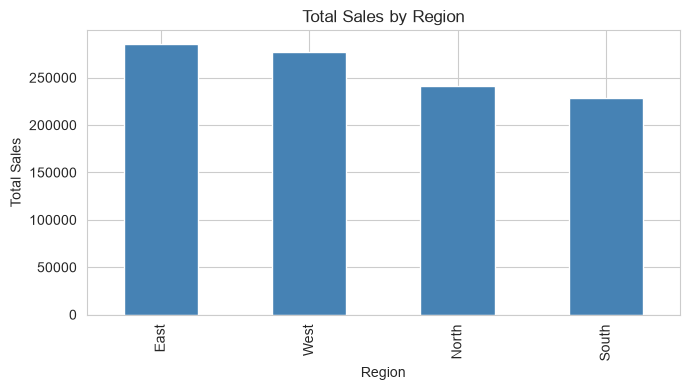

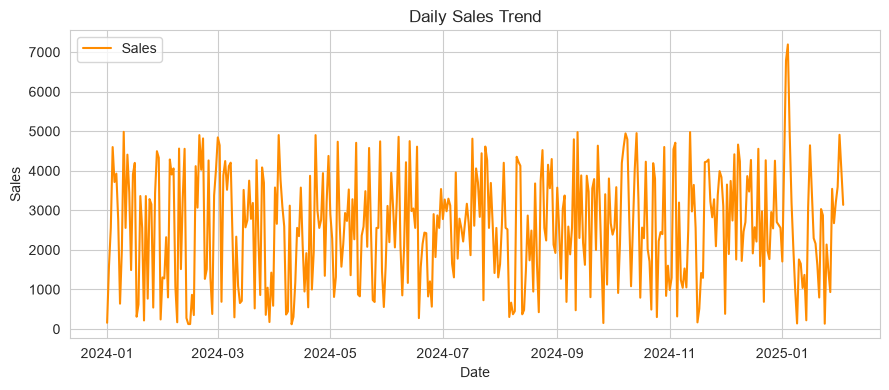

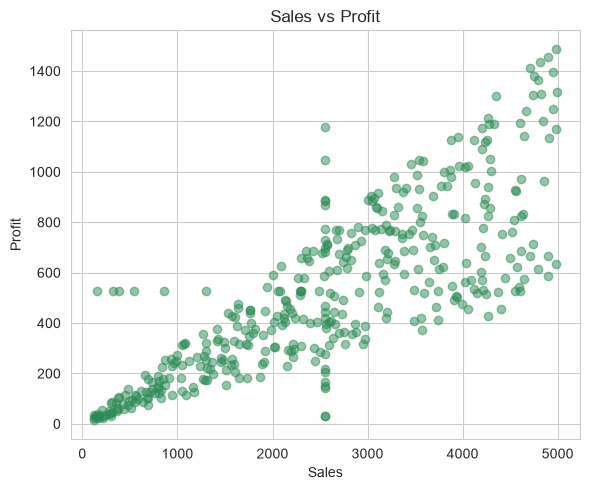

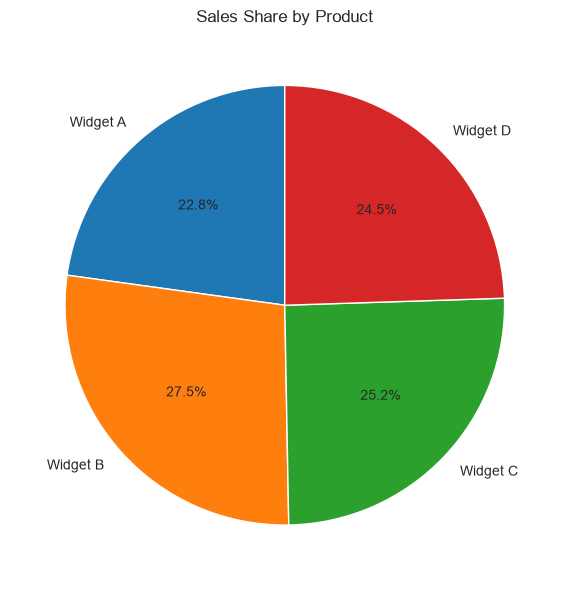

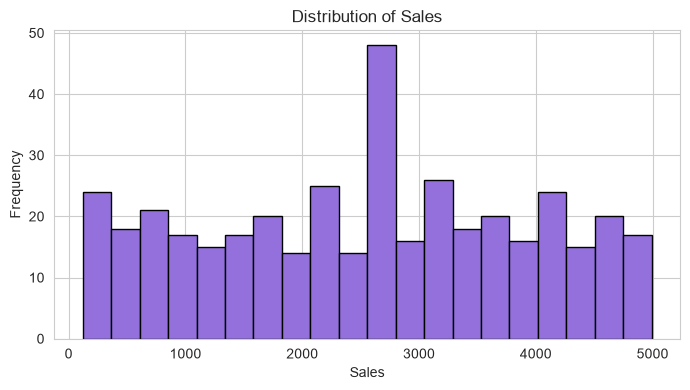

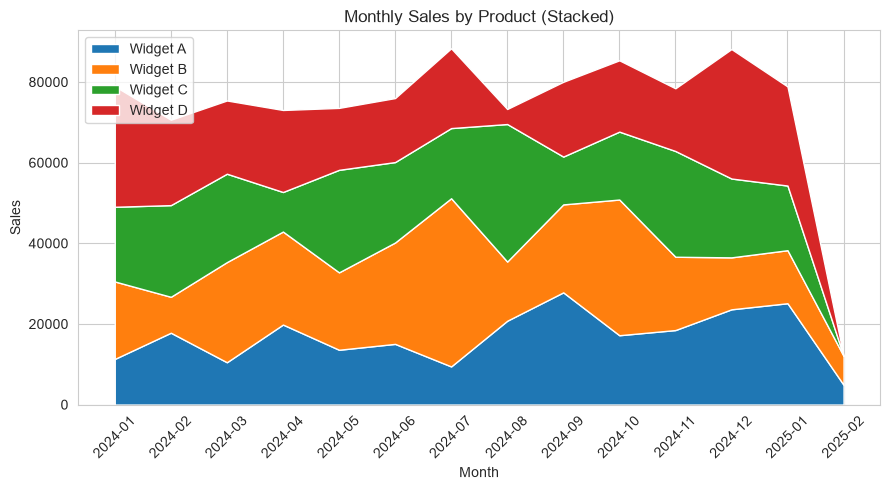

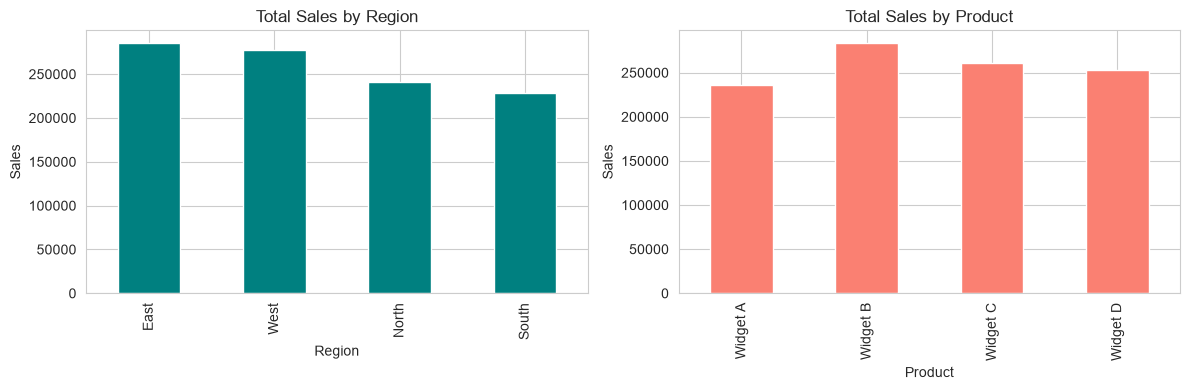

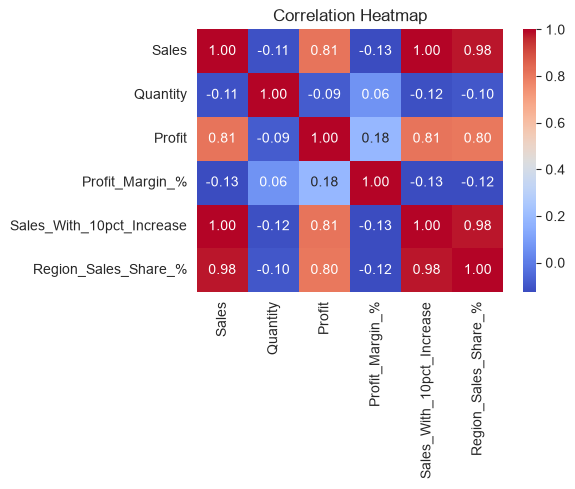

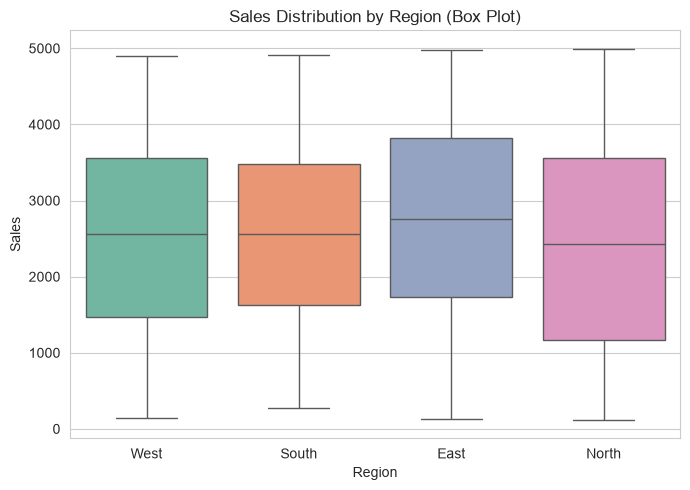

All visualizations saved to the 'plots/' directory.


In [18]:
analyzer.visualize_data(save_dir='plots')

In [19]:
north_analyzer = RegionalSalesAnalyzer(CSV_PATH, region='North')
north_analyzer.explore_data()

Data loaded successfully from 'sales_data.csv'. Shape: (400, 6)
[SalesDataAnalyzer] Instance created for 'sales_data.csv'.
>>> Regional analysis for: North <<<
HEAD (first 5 rows)
        Date   Product Region   Sales  Quantity   Profit
0 2024-01-08  Widget C  North   641.0        36    86.27
1 2024-01-10  Widget A  North  4985.0        48  1487.30
2 2024-01-11  Widget C  North     NaN        31    31.85
3 2024-01-12  Widget D  North  4408.0        39   455.42
4 2024-01-14  Widget D  North  1491.0        43   323.44

INFO
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      99 non-null     datetime64[us]
 1   Product   99 non-null     str           
 2   Region    99 non-null     str           
 3   Sales     92 non-null     float64       
 4   Quantity  99 non-null     int64         
 5   Profit    95 non-null     float64       
dtypes: datet

In [20]:
def main_menu(analyzer):
    menu_text = '\n    ============================\n     SALES DATA ANALYZER MENU\n    ============================\n    1. Explore Data\n    2. Clean Data\n    3. Mathematical Operations\n    4. Search / Sort / Filter\n    5. Aggregate Functions\n    6. Statistical Analysis\n    7. Create Pivot Table\n    8. Visualize Data\n    9. Export Results\n    0. Exit\n    ============================\n    '
    while True:
        print(menu_text)
        choice = input('Enter your choice (0-9): ').strip()
        if choice == '1':
            analyzer.explore_data()
        elif choice == '2':
            analyzer.clean_data()
        elif choice == '3':
            analyzer.mathematical_operations()
        elif choice == '4':
            col = input('Search which column? (e.g., Product): ') or 'Product'
            val = input('Search for value: ')
            print(analyzer.search_sort_filter(search_value=val, search_column=col).head())
        elif choice == '5':
            group_col = input('Group by which column? (e.g., Region): ') or 'Region'
            analyzer.aggregate_functions(group_by=group_col)
        elif choice == '6':
            analyzer.statistical_analysis()
        elif choice == '7':
            analyzer.create_pivot_table()
        elif choice == '8':
            analyzer.visualize_data()
        elif choice == '9':
            analyzer.export_results()
        elif choice == '0':
            print('Exiting program. Goodbye!')
            break
        else:
            print('Invalid choice, please try again.')
print('main_menu() defined. Call main_menu(analyzer) in an interactive session to use it.')

main_menu() defined. Call main_menu(analyzer) in an interactive session to use it.


In [21]:
analyzer.export_results('analysis_results.csv')
print('\nSaved visualization files:')
for f in sorted(os.listdir('plots')):
    print(' -', os.path.join('plots', f))

Analysis results exported to 'analysis_results.csv'.

Saved visualization files:
 - plots\bar_sales_by_region.png
 - plots\boxplot_sales_by_region.png
 - plots\heatmap_correlation.png
 - plots\hist_sales_distribution.png
 - plots\line_sales_trend.png
 - plots\pie_sales_by_product.png
 - plots\scatter_sales_vs_profit.png
 - plots\stackplot_monthly_sales.png
 - plots\subplots_region_product.png
